## Datasets

1. https://www.kaggle.com/datasets/googleai/musiccaps?select=musiccaps-public.csv
¿validación?

https://ismir.net/resources/datasets/

2. https://github.com/mdeff/fma -> medium

Todos los metadatos y características de todas las pistas se distribuyen en fma_metadata.zip(342 MiB).

* tracks.csv:metadatos por pista, como ID, título, artista, géneros, etiquetas y cantidades de reproducciones, para las 106.574 pistas.  
* genres.csv: los 163 géneros con nombre y padre (usado para inferir la jerarquía de géneros y los géneros de nivel superior).  
* features.csv:características comunes extraídas con librosa.  
* echonest.csv: funciones de audio proporcionadas por Echonest (ahora Spotify ) para un subconjunto de 13.129 pistas.  

Luego tienes varios tamaños de datos de audio codificados en MP3:

* fma_small.zip:8000 pistas de 30 segundos, 8 géneros equilibrados (similares a GTZAN) (7,2 GiB)
* fma_medium.zip:25.000 pistas de 30 segundos, 16 géneros no equilibrados (22 GiB) <-
* fma_large.zip:106.574 pistas de 30 segundos, 161 géneros desequilibrados (93 GiB)
* fma_full.zip:106.574 pistas sin recortar, 161 géneros desequilibrados (879 GiB)

### Descarga del dataset

In [ ]:
!wget https://os.unil.cloud.switch.ch/fma/fma_medium.zip

--2025-11-24 03:50:01--  https://os.unil.cloud.switch.ch/fma/fma_medium.zip
Resolving os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)... 86.119.28.16, 2001:620:5ca1:201::214
Connecting to os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)|86.119.28.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23825005356 (22G) [application/zip]
Saving to: ‘fma_medium.zip.1’

fma_medium.zip.1      0%[                    ] 115.08M  60.3MB/s               ^C


In [ ]:
import shutil
import os

origen = '/content/fma_medium.zip'
destino = '/content/drive/MyDrive/AnteproyectoTerminal/Código/fma_medium.zip'
os.makedirs(os.path.dirname(destino), exist_ok=True)

shutil.move(origen, destino)

Moviendo /content/fma_medium.zip a /content/drive/MyDrive/AnteproyectoTerminal/Código/fma_medium.zip...
¡Movimiento completado! El dataset FMA_medium está ahora en tu Google Drive.


In [ ]:
ruta_destino_descomprimido = '/content/drive/MyDrive/AnteproyectoTerminal/Código/fma_medium'
print("Iniciando descompresión. Esto tomará varios minutos...")
!unzip -q "{destino}" -d "{ruta_destino_descomprimido}"

Iniciando descompresión. Esto tomará varios minutos...

✅ ¡Descompresión completada!
Los 25,000 audios de FMA Medium están ahora listos en la carpeta: /content/drive/MyDrive/AnteproyectoTerminal/Código/fma_mediumfma_medium


## Librerías

In [10]:
!pip install librosa

In [51]:
!pip install resampy

   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.1 MB 330.3 kB/s eta 0:00:10
    --------------------------------------- 0.0/3.1 MB 281.8 kB/s eta 0:00:11
   - -------------------------------------- 0.1/3.1 MB 476.3 kB/s eta 0:00:07
   -- ------------------------------------- 0.2/3.1 MB 888.4 kB/s eta 0:00:04
   ---- ----------------------------------- 0.3/3.1 MB 1.3 MB/s eta 0:00:03
   ------ --------------------------------- 0.5/3.1 MB 1.7 MB/s eta 0:00:02
   ---------- ----------------------------- 0.8/3.1 MB 2.1 MB/s eta 0:00:02
   -------------- ------------------------- 1.1/3.1 MB 2.7 MB/s eta 0:00:01
   ----------------- ---------------------- 1.4/3.1 MB 3.0 MB/s eta 0:00:01
   --------------------- ------------------ 1.6/3.1 MB 3.2 MB/s eta 0:00:01
   ----------------------

In [1]:
import os
# Establece 'soundfile' como el backend de decodificación de audio
# os.environ['LIBROSA_AUDIO_BACKEND'] = 'soundfile' 

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import os
# from google.colab import drive
from concurrent.futures import ProcessPoolExecutor

# Ruta base donde se guardó el dataset FMA_medium
# path_fma = '/content/drive/MyDrive/AnteproyectoTerminal/Código/fma_medium/fma_medium/'
path_fma = 'Data/fma_medium/fma_medium/'

## Dataset base GTZAN Dataset - Music Genre Classification

| Columna                   | Descripción |
|----------------------------|-------------|
| filename                   | Nombre del archivo de audio analizado. |
| length                     | Duración del audio (en segundos o muestras). |
| chroma_stft_mean           | Media del Chroma STFT (energía en notas musicales). |
| chroma_stft_var            | Varianza del Chroma STFT. |
| rms_mean                   | Media de la energía RMS (intensidad promedio). |
| rms_var                    | Varianza de la energía RMS. |
| spectral_centroid_mean     | Media del centroide espectral (indica el brillo del sonido). |
| spectral_centroid_var      | Varianza del centroide espectral. |
| spectral_bandwidth_mean    | Media del ancho de banda espectral (amplitud de frecuencias activas). |
| spectral_bandwidth_var     | Varianza del ancho de banda espectral. |
| rolloff_mean               | Media del Spectral Roll-off (frecuencia donde se concentra el 85% de la energía). |
| rolloff_var                | Varianza del Spectral Roll-off. |
| zero_crossing_rate_mean    | Media de la tasa de cruces por cero (ruidosidad del audio). |
| zero_crossing_rate_var     | Varianza de la tasa de cruces por cero. |
| harmony_mean               | Media de la armonía (estructura tonal). |
| harmony_var                | Varianza de la armonía. |
| perceptr_mean              | Media de la percepción tonal (perceptual pitch). |
| perceptr_var               | Varianza de la percepción tonal. |
| tempo                      | Tempo estimado (BPM). |
| mfcc1_mean                 | Media del coeficiente MFCC 1. |
| mfcc1_var                  | Varianza del coeficiente MFCC 1. |
| mfcc2_mean                 | Media del coeficiente MFCC 2. |
| mfcc2_var                  | Varianza del coeficiente MFCC 2. |
| mfcc3_mean                 | Media del coeficiente MFCC 3. |
| mfcc3_var                  | Varianza del coeficiente MFCC 3. |
| mfcc4_mean                 | Media del coeficiente MFCC 4. |
| mfcc4_var                  | Varianza del coeficiente MFCC 4. |
| mfcc5_mean                 | Media del coeficiente MFCC 5. |
| mfcc5_var                  | Varianza del coeficiente MFCC 5. |
| mfcc6_mean                 | Media del coeficiente MFCC 6. |
| mfcc6_var                  | Varianza del coeficiente MFCC 6. |
| mfcc7_mean                 | Media del coeficiente MFCC 7. |
| mfcc7_var                  | Varianza del coeficiente MFCC 7. |
| mfcc8_mean                 | Media del coeficiente MFCC 8. |
| mfcc8_var                  | Varianza del coeficiente MFCC 8. |
| mfcc9_mean                 | Media del coeficiente MFCC 9. |
| mfcc9_var                  | Varianza del coeficiente MFCC 9. |
| mfcc10_mean                | Media del coeficiente MFCC 10. |
| mfcc10_var                 | Varianza del coeficiente MFCC 10. |
| mfcc11_mean                | Media del coeficiente MFCC 11. |
| mfcc11_var                 | Varianza del coeficiente MFCC 11. |
| mfcc12_mean                | Media del coeficiente MFCC 12. |
| mfcc12_var                 | Varianza del coeficiente MFCC 12. |
| mfcc13_mean                | Media del coeficiente MFCC 13. |
| mfcc13_var                 | Varianza del coeficiente MFCC 13. |
| mfcc14_mean                | Media del coeficiente MFCC 14. |
| mfcc14_var                 | Varianza del coeficiente MFCC 14. |
| mfcc15_mean                | Media del coeficiente MFCC 15. |
| mfcc15_var                 | Varianza del coeficiente MFCC 15. |
| mfcc16_mean                | Media del coeficiente MFCC 16. |
| mfcc16_var                 | Varianza del coeficiente MFCC 16. |
| mfcc17_mean                | Media del coeficiente MFCC 17. |
| mfcc17_var                 | Varianza del coeficiente MFCC 17. |
| mfcc18_mean                | Media del coeficiente MFCC 18. |
| mfcc18_var                 | Varianza del coeficiente MFCC 18. |
| mfcc19_mean                | Media del coeficiente MFCC 19. |
| mfcc19_var                 | Varianza del coeficiente MFCC 19. |
| mfcc20_mean                | Media del coeficiente MFCC 20. |
| mfcc20_var                 | Varianza del coeficiente MFCC 20. |
| label                      | Etiqueta o clase del audio (ej. género, artista, emoción, etc.). |


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AnteproyectoTerminal/Código/GTZAN Dataset/features_30_sec.csv")

In [ ]:
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


## Creación de Espectrogramas - Ejemplo

Notas:

***Serie de Tiempo (y)*** Es la señal de audio en su forma más básica. Cuando se graba un sonido, el micrófono mide la presión del aire en un momento dado.*librosa.load()* convierte el archivo MP3 en una array de números flotantes de NumPy. Cada número representa la amplitud (o intensidad) del sonido en un instante muy breve. El valor de la amplitud está ordenado en función del Sample  
  
***Rate (sr)*** Es la Frecuencia de Muestreo (Sampling Rate). Indica cuántas veces por segundo se muestrea la señal de audio. El valor estándar de sr=22050 significa que la amplitud del audio se mide 22,050 veces por segundo (22.05 kHz). Este es el valor por defecto, es la mitad de la calidad de CD (44.1 kHz).


***STFT (Short-Time Fourier Transform)*** Rompe la señal de audio en pequeñas ventanas y aplica la Transformada de Fourier a cada fragmento, lo que indica qué frecuencias estaban presentes en ese breve momento, creando la matriz de tiempo-frecuencia.
  
***Escala de Decibelios (dB)*** Convertir la amplitud a la escala de decibelios (dB) hace que la imagen del espectrograma sea mucho más similar a cómo escuchamos y resalta las diferencias de volumen de manera más clara.  
  
***melspectrogram*** En lugar de representar las frecuencias linealmente las representa en la escala Mel, una escala que se aproxima a cómo el oído humano discrimina las frecuencias. El oído es mucho más sensible a los cambios de frecuencia en los graves que en los agudos.  
  
***Potencia en dB ***  Se convierte la potencia (el cuadrado de la amplitud) a la escala logarítmica de decibelios para una mejor representación visual y computacional.

In [3]:
def generar_espectrogramas(ruta_archivo, sr=22050):
    y, sr = librosa.load(ruta_archivo, sr=sr) # 'y' es la serie de tiempo del audio, 'sr' es el sample rate

    # Espectrograma BÁSICO -
    # La función STFT convierte la señal de tiempo a dominio de frecuencia-tiempo
    D = librosa.stft(y)
    # Se toma el absoluto de los num complejos para mantener la amplitud de la frecuencia (volumen)
    S_amplitude = np.abs(D)
    # Convierte a escala de decibelios (dB) para mejor visualización
    S_dB = librosa.amplitude_to_db(S_amplitude, ref=np.max)

    # Mel Espectrograma, para obtención de MFCCs (Coeficientes Cepstrales en la Frecuencia Mel)
    S_mel = librosa.feature.melspectrogram(y=y, sr=sr, S=S_amplitude**2)
    S_mel_dB = librosa.power_to_db(S_mel, ref=np.max)

    return S_dB, S_mel_dB, sr

Prueba

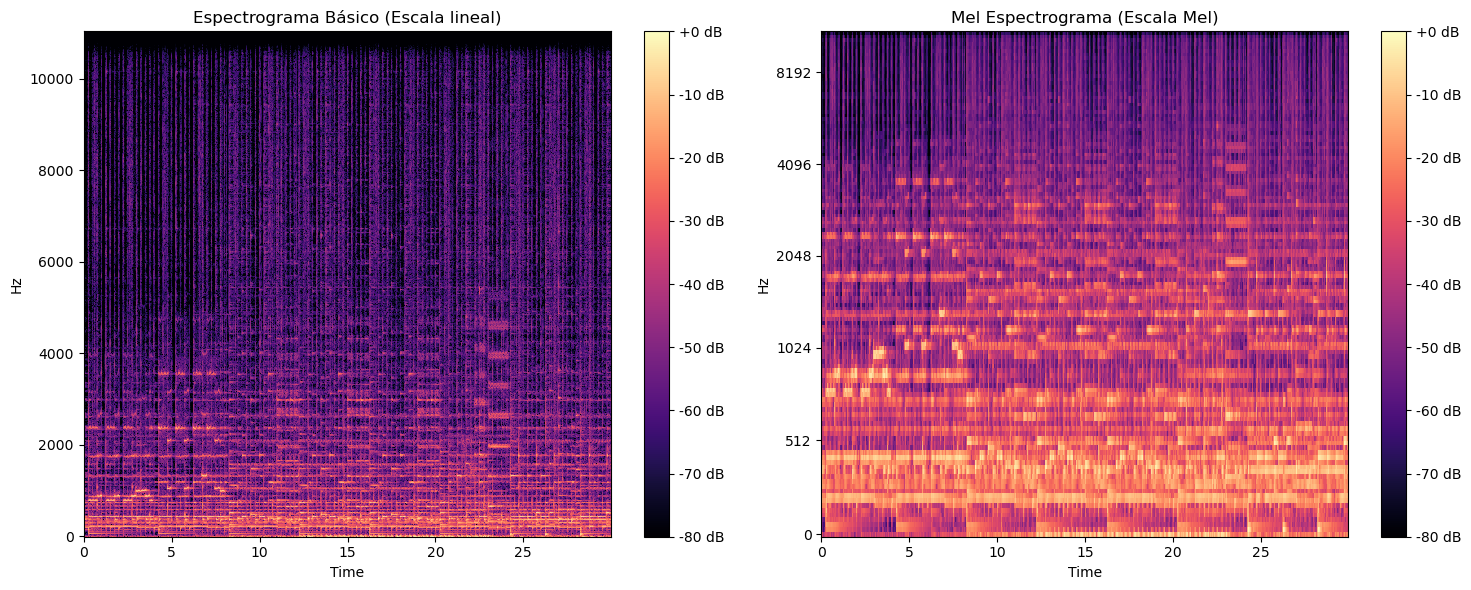

In [14]:
ruta_ejemplo = path_fma + '155/155000.mp3'

if os.path.exists(ruta_ejemplo):
    S_dB, S_mel_dB, sr = generar_espectrogramas(ruta_ejemplo)

    # Visualización de los dos tipos
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Espectrograma Básico
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='hz', ax=axes[0])
    axes[0].set(title='Espectrograma Básico (Escala lineal)')
    fig.colorbar(axes[0].collections[0], ax=axes[0], format='%+2.0f dB')

    # Mel Espectrograma
    librosa.display.specshow(S_mel_dB, sr=sr, x_axis='time', y_axis='mel', ax=axes[1])
    axes[1].set(title='Mel Espectrograma (Escala Mel)')
    fig.colorbar(axes[1].collections[0], ax=axes[1], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

In [16]:
import librosa
import numpy as np

# 1. Carga el audio usando el Sample Rate real de tu proyecto (ej. 22050 Hz).
# Esto te asegura que la señal 'y' es consistente.
y, sr = librosa.load(ruta_ejemplo, sr=22050) 

# 2. Fuerza el tipo de dato a float32 para consistencia numérica.
# (Esta sigue siendo la parte clave para la reproducibilidad)
y = y.astype(np.float32) 

In [17]:
y

array([ 7.4505806e-09,  7.4505806e-09, -3.7252903e-09, ...,
       -1.2624559e-01, -1.2794647e-01, -7.7740826e-02], dtype=float32)

In [19]:
fma_features(ruta_ejemplo)

DEBUG: Intentando procesar ID 155000


[155000,
 1405.7633075191882,
 144666.9373969859,
 1800.7562237412928,
 185806.11732974078,
 2843.8137619470576,
 1150211.5918115722,
 0.06529559585168135,
 0.00047008027363135694,
 0.1567902,
 0.0018192355,
 0.19805443,
 0.07154241,
 -0.010985426,
 0.019985355,
 -0.00037697394,
 0.0021713707,
 -141.0935516357422,
 138.8606719970703,
 -10.694001197814941,
 26.915983200073242,
 -0.8375575542449951,
 5.002898216247559,
 -16.57882308959961,
 0.4230397939682007,
 -21.604808807373047,
 1.3298827409744263,
 -14.52371883392334,
 2.297635316848755,
 -13.952628135681152,
 -0.34756556153297424,
 -10.637214660644531,
 1.9599941968917847,
 -4.242514133453369,
 9.483133316040039,
 2.57089900970459,
 9.317580223083496,
 52.75606155395508,
 24.183115005493164,
 17.113725662231445,
 11.094696998596191,
 9.262786865234375,
 13.226326942443848,
 8.43427848815918,
 9.67593765258789,
 10.550522804260254,
 9.995078086853027,
 10.324481964111328,
 10.920654296875,
 10.848031997680664,
 11.357667922973633,
 

**Espectrograma básico**  
*Eje X (Time):* Representa la duración de la canción (en este caso, aproximadamente 30 segundos).  
*Eje Y (Hz):* Muestra la Frecuencia en una escala lineal (Hercios o ciclos por segundo). Puedes ver 0 Hz en la parte inferior hasta 11,000 Hz o más en la parte superior.  
*Intensidad (Color):* Muestra la Amplitud (volumen o energía) en decibelios (dB). Los colores más brillantes (cercanos a 0 dB) indican que esa frecuencia específica era muy fuerte en ese momento.  

Este espectrograma muestra el contenido armónico de la música de una manera físicamente precisa, donde la separación de las frecuencias siempre es la misma (por ejemplo, la distancia entre 1000 Hz y 2000 Hz es la misma que entre 8000 Hz y 9000 Hz).

**Espectrograma básico**  
*Eje X (Time):* Representa la duración de la canción (en este caso, aproximadamente 30 segundos).  
*Eje Y (Hz):* Muestra la Frecuencia en la Escala Mel. Esta escala es logarítmica y se aproxima a la forma en que el oído humano percibe las frecuencias.  
La escala Mel tiene más resolución para las frecuencias bajas (graves) y menos para las altas (agudos).  

Las líneas de frecuencia están más espaciadas en la parte inferior (bajas frecuencias) y se comprimen en la parte superior. Esto es un reflejo de que el oído es más sensible a los pequeños cambios en los tonos graves.

## Extracción de características

In [12]:
path_csv = path_fma + "features_2.csv"

In [18]:
# Función que extrae las características del audio alojado en "path"
# Parámetros
# path: donde se aloja el audio
def fma_features(path):
    n_mfcc=20 # Número de coeficientes MFCC
    sr=22050

    # Extraer el ID de la pista
    id = int(os.path.basename(path)[:-4])
    print(f"DEBUG: Intentando procesar ID {id}") # <--- LÍNEA DE DEPURACIÓN CLAVE

    try:
        # Cargar el audio, limitado a 29.0 segundos
        # y, sr = librosa.load(path, sr=sr, duration=29.0)
        y, sr = librosa.load(path, sr=sr, duration=29.0, res_type='kaiser_fast')
        y = y.astype(np.float32) 

        features = []
        # Extracción de 57 características (SPECTRAL, RMS, CHROMA, MFCC, TEMPO)

        # Características Espectrales (8 campos)

        # spectral_centroid_mean/var: Media/Varianza del centroide espectral (indica el brillo del sonido).
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
        features.extend([np.mean(centroid), np.var(centroid)])

        # spectral_bandwidth_mean/var: Media/Varianza del ancho de banda espectral (amplitud/densidad de frecuencias activas).
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
        features.extend([np.mean(bandwidth), np.var(bandwidth)])

        # rolloff_mean/var: Media/Varianza del Spectral Roll-off (frecuencia donde se concentra el 85% de la energía).
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
        features.extend([np.mean(rolloff), np.var(rolloff)])

        # zero_crossing_rate_mean/var: Media/Varianza de la tasa de cruces por cero (ruidosidad del audio).
        zcr = librosa.feature.zero_crossing_rate(y)[0]
        features.extend([np.mean(zcr), np.var(zcr)])

        # Características de Energía y Cromáticas (4 campos)

        # rms_mean/var: Media/Varianza de la energía RMS (intensidad promedio).
        rms = librosa.feature.rms(y=y)[0]
        features.extend([np.mean(rms), np.var(rms)])

        # chroma_stft_mean/var: Media/Varianza del Chroma STFT (energía en notas musicales).
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)[0]
        features.extend([np.mean(chroma), np.var(chroma)])

        # Características Perceptuales (4 campos)

        # Separación Armónica/Percusiva
        y_harm, y_perc = librosa.effects.hpss(y)

        # harmony_mean/var: Media/Varianza de la armonía (estructura tonal).
        features.extend([np.mean(y_harm), np.var(y_harm)])

        # perceptr_mean/var: Media/Varianza de la percepción tonal (perceptual pitch/percusión).
        features.extend([np.mean(y_perc), np.var(y_perc)])

        # MFCCs (40 campos)

        # mfcc[1-20]_mean/var: Media/Varianza de los coeficientes MFCC (timbre).
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        # Media de los 20 coeficientes
        features.extend(np.mean(mfccs, axis=1).tolist())

        # Desviación estándar (Varianza) de los 20 coeficientes
        features.extend(np.std(mfccs, axis=1).tolist())

        # Ritmo (1 campo)

        # tempo: Tempo estimado (BPM).
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        features.append(tempo)

        # Se retorna el id y el vector con las 57 características
        return [id] + features

    except Exception as e:
        # Captura CUALQUIER error (I/O, corrupción, formato) y previene la caída del Pool
        print(f"ERROR: Fallo al procesar el ID {id} ({os.path.basename(path)}). Causa: {e}")
        return None # Siempre retorna None en caso de fallo

In [7]:
# Función que guarda el csv
# Parámetros
# path: ruta del archivo
# header: bandera que indica si se escribe o no el encabezado
def save_csv(df, path, header):
    df.to_csv(path,
              mode='a',
              header=header,
              index=False)

In [8]:
# Función que genera los encabezados del dataframe
def get_headers():
    # MFCCs (20 coeficientes x 2 estadísticas = 40 campos)
    mfcc_columns = []
    for i in range(1, 21):
        mfcc_columns.append(f'mfcc{i}_mean')
    for i in range(1, 21):
        mfcc_columns.append(f'mfcc{i}_var')

    header_list = [
        # Spectral (8)
        'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var',
        'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
        # RMS (2)
        'rms_mean', 'rms_var',
        # Chroma (2)
        'chroma_stft_mean', 'chroma_stft_var',
        # Perceptual (4)
        'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var',
        # MFCCs (40)
        *mfcc_columns, # Esto añade la lista de 40 MFCCs (mean y var)
        # Tempo (1)
        'tempo'
    ]

    # Añadir el ID al inicio
    final_header = ['id'] + header_list

    return final_header

In [9]:
# Revisa el CSV guardado y retorna el ID de pista más alto (última canción procesada).
def get_last_processed_id(path_csv):
    if os.path.exists(path_csv):
        try:
            df = pd.read_csv(path_csv, usecols=['id'], dtype={'id': int})
            return df['id'].max()
        except Exception:
            return
    return -1

In [10]:
# Lista de todas las subcarpetas del FMA Medium (de 000 a 155)
subfolder_fma = [f'{i:03d}' for i in range(156)]

# Inicializar banderas de control
header_f = not os.path.exists(path_fma) # Si el archivo no existe, guardar el encabezado.
file_processed = 0 # Contador de archivos procesados

In [11]:
N_WORKERS = os.cpu_count() or 4
last_id = get_last_processed_id(path_csv)
header_flag = (last_id == -1)

In [13]:
# 🚨 CAMBIO DE IMPORTACIÓN: Usar ThreadPoolExecutor para estabilidad en Notebooks 🚨
from concurrent.futures import ThreadPoolExecutor 
# Debes tener las demás importaciones: import os, import time, import pandas as pd


# ==============================================================================
# 1. LÓGICA DE REANUDACIÓN Y CONFIGURACIÓN (CORREGIDA)
# ==============================================================================

start_folder_name = None
if last_id > -1:
    # La carpeta se calcula dividiendo el ID entre 1000 y formateando a 3 dígitos
    start_folder_index = last_id // 1000
    start_folder_name = f'{start_folder_index:03d}'
else:
    start_folder_name = "000"

# Bandera que indica si ya encontramos la carpeta donde debemos empezar
# CORRECCIÓN: Si last_id es -1 (inicio), empezamos inmediatamente (True).
started_processing = (last_id == -1) 

# Inicializar o cargar el contador de archivos procesados
if header_flag:
  file_processed = 0
else:
  try:
    file_processed = len(pd.read_csv(path_csv, usecols=['id'], dtype={'id': int}))
  except:
    file_processed = 0

print(f"Estado de reanudación: Último ID procesado: {last_id}. Total actual: {file_processed} archivos.")
print(f"Utilizando {N_WORKERS} hilos de CPU para el procesamiento por lotes.")
print(f"Carpeta de inicio calculada: {start_folder_name}")


# ==============================================================================
# 2. BUCLE PRINCIPAL (CON THREADING)
# ==============================================================================

# Guardar por lotes
for i, s in enumerate(subfolder_fma):
    
    # LÓGICA DE SALTO DE CARPETA COMPLETA
    if not started_processing:
        if s != start_folder_name:
            print(f"Saltando subcarpeta completa: {s} (previa a la carpeta: {start_folder_name})")
            continue
        else:
            # Una vez que encontramos la carpeta de inicio, activamos el procesamiento
            started_processing = True
            # Continuamos el bucle, ahora SÍ procesaremos esta carpeta.

    # Se crea el path completo de la subcarpeta
    subfolder_path = os.path.join(path_fma, s)
    print(subfolder_path)

    if not os.path.isdir(subfolder_path):
      continue # Ignora si la carpeta no existe

    batch_files_to_process = []

    # Filtrar solo archivos nuevos (Se mantiene la estrategia de reprocesar el lote)
    for file in os.listdir(subfolder_path):
      if file.endswith('.mp3'):
        current_id = int(file[:-4])
        whole_path = os.path.join(subfolder_path, file)
        batch_files_to_process.append(whole_path)

    if not batch_files_to_process:
      if last_id != -1 and started_processing:
        print(f"   Subcarpeta {s} ya completada o no contiene nuevos archivos. Saltando.")
        continue # Si la carpeta está vacía o ya fue procesada, continuar

    print(f"\n--- Procesando subcarpeta {s} con ({len(batch_files_to_process)} archivos) ---")

    start_time_batch = time.time()

    # Extracción de características para el lote
    batch_data = []

    # 🚨 USO DE THREADPOOL (Más estable en Windows Notebook) 🚨
    with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
        # Mapea fma_features a la lista de archivos para ejecución paralela
        resultados_lote = executor.map(fma_features, batch_files_to_process)

        # Recolectar resultados de los procesos (ahora hilos)
        for vector in resultados_lote:
            if vector is not None:
              batch_data.append(vector)
              print(vector)


    # Creación de DataFrame y Guardado
    if batch_data:
      headers_list = get_headers()
      df_lote = pd.DataFrame(batch_data, columns=headers_list)

      save_csv(df_lote, path_csv, header_flag)
      header_flag = False
      file_processed += len(batch_data)
      time_t = time.time() - start_time_batch

      last_id = df_lote['id'].max()

      print(f"Subcarpeta {s} procesada. {len(batch_data)} archivos guardados en {time_t:.2f}s.")
      print(f"Último ID guardado: {last_id}. Total acumulado: {file_processed}")

print("\n\n=============== PROCESO DE EXTRACCIÓN FINALIZADO ===============")

Estado de reanudación: Último ID procesado: 155314. Total actual: 0 archivos.
Utilizando 4 hilos de CPU para el procesamiento por lotes.
Carpeta de inicio calculada: 155
Saltando subcarpeta completa: 000 (previa a la carpeta: 155)
Saltando subcarpeta completa: 001 (previa a la carpeta: 155)
Saltando subcarpeta completa: 002 (previa a la carpeta: 155)
Saltando subcarpeta completa: 003 (previa a la carpeta: 155)
Saltando subcarpeta completa: 004 (previa a la carpeta: 155)
Saltando subcarpeta completa: 005 (previa a la carpeta: 155)
Saltando subcarpeta completa: 006 (previa a la carpeta: 155)
Saltando subcarpeta completa: 007 (previa a la carpeta: 155)
Saltando subcarpeta completa: 008 (previa a la carpeta: 155)
Saltando subcarpeta completa: 009 (previa a la carpeta: 155)
Saltando subcarpeta completa: 010 (previa a la carpeta: 155)
Saltando subcarpeta completa: 011 (previa a la carpeta: 155)
Saltando subcarpeta completa: 012 (previa a la carpeta: 155)
Saltando subcarpeta completa: 013 (pr